In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

In [2]:
# 1. Data Loading and Inspection
df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape (rows, cols): ", df.shape)
print("Datatypes: ", df.dtypes)
print("Missing Value Counts: ", df.isna().sum())
df.head()

Shape (rows, cols):  (800, 12)
Datatypes:  age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object
Missing Value Counts:  age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


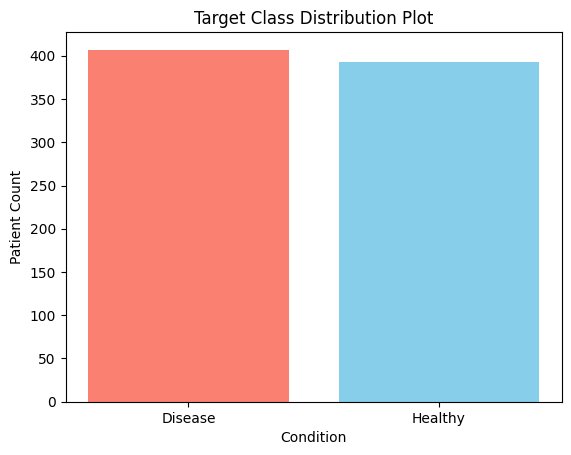

In [3]:
# 2. Exploratory Data Analysis
# Target Class Distribution Plot
plt.figure()
counts = df['heart_disease'].value_counts()
plt.bar(counts.index.map({0: 'Healthy', 1: 'Disease'}), counts.values, color=['salmon', 'skyblue'])
plt.title("Target Class Distribution Plot")
plt.xlabel("Condition")
plt.ylabel("Patient Count")
plt.show()


The above graph is a simple bar graph showing the number of patients that are healthy and number of patients that have heart disease. The salmon (peach) colour show the amount of patients with a heart disease, and the light blue colour shows the amount of people who are healthy. The number of healthy people and heart disease patients are roughly similar, this means that the dataset has almost equal categories, that is, it is balanced. 

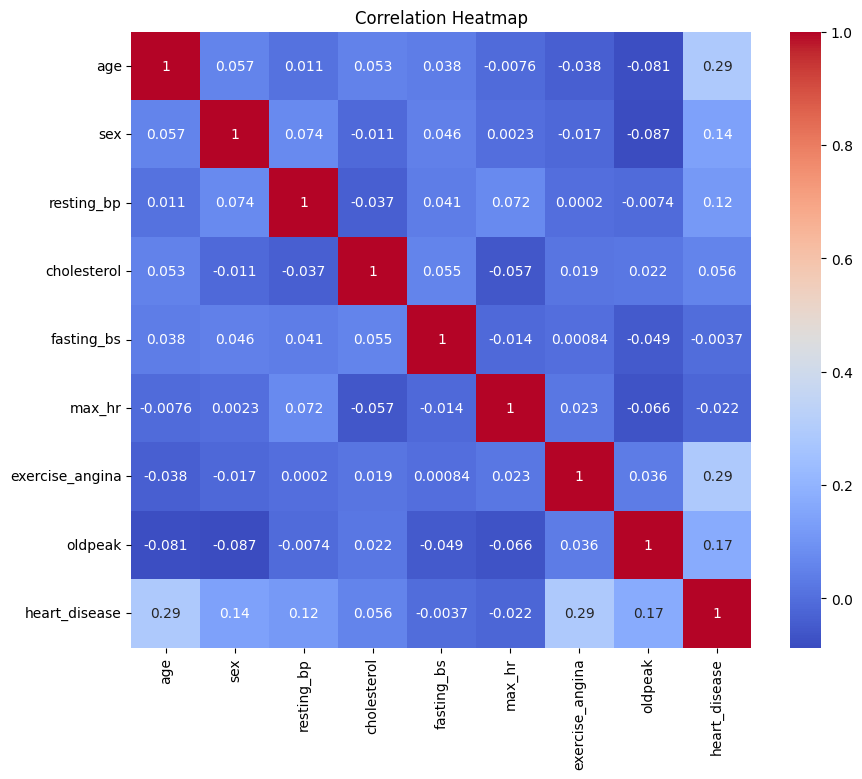

In [4]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()


The above graph is a heatmap showing the correlation between age, gender, resting blood pressure, cholesterol, fasting blood sugar, maximum heart rate, exercise angina, oldpeak, and heart disease. colours in red or values closer to 1 show strong correlation. Colours closer to dark blue show less correlation, as per the scale. The age and exercise angina (0.29) show the most contribution to heart disease, and fasting blood sugar (-0.0037) does not contribute much to heart diease.

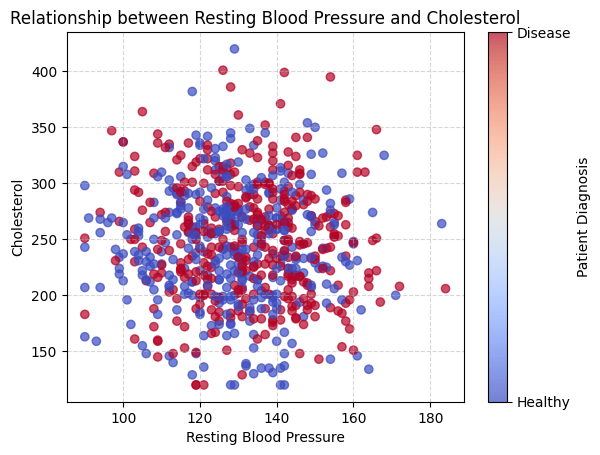

In [5]:
# Relationship between Resting Blood Pressure and Cholesterol
plt.figure()
scatter = plt.scatter(df['resting_bp'], df['cholesterol'], c = df['heart_disease'], cmap = 'coolwarm', alpha = 0.7)
cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1]) 
cbar.set_ticklabels(['Healthy', 'Disease'])
cbar.set_label('Patient Diagnosis')
plt.title("Relationship between Resting Blood Pressure and Cholesterol")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Cholesterol")
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

The above graph shows a scatter plot between cholesterol and resting blood pressure. The blue points mark the healthy peole and red points mark patients with heart disease. In this case, there isn't a clear definition between the points, which means that peole with high blood pressure and cholesterol readings can be healthy and vice versa. 

In [ ]:
# 3. Data Preprocessing
print("before imputation", df.isna().sum().sum())
df = df.fillna(df.median(numeric_only=True))
print("after imputation", df.isna().sum().sum())

df = pd.get_dummies(df, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

before imputation 56
after imputation 0


Row Drop is used to drop rows with NaN or null, but is used on large datasets where dropping a few rows wouldn't affect the dataset much. Since the given heart_disease dataset is quite small, we will use median imputation. To fill any null values, we fill it with median values of the dataset. like a guess. We use numeric_only=True so it doesn't try to find the median of words

Decision Tree Accuracy =  0.70625
Decision Tree Precision =  0.717948717948718
Decision Tree Recall =  0.691358024691358
Decision Tree F1 Score =  0.7044025157232704


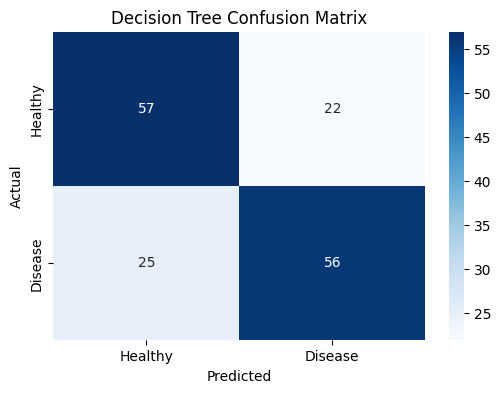

In [7]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
print("Decision Tree Accuracy = ", accuracy_score(y_test, dt_pred))
print("Decision Tree Precision = ", precision_score(y_test, dt_pred))
print("Decision Tree Recall = ", recall_score(y_test, dt_pred))
print("Decision Tree F1 Score = ", f1_score(y_test, dt_pred))

cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

Random Forest Accuracy =  0.79375
Random Forest Precision =  0.7857142857142857
Random Forest Recall =  0.8148148148148148
Random Forest F1 Score =  0.8


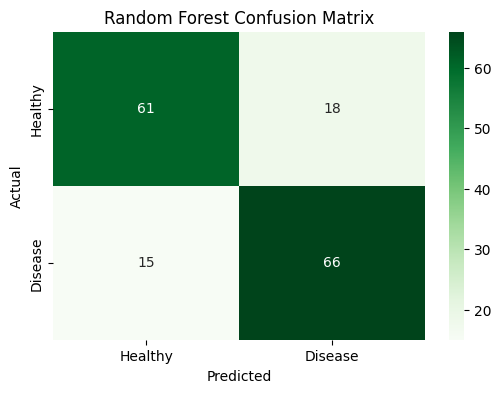

In [8]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("Random Forest Accuracy = ", accuracy_score(y_test, rf_pred))
print("Random Forest Precision = ", precision_score(y_test, rf_pred))
print("Random Forest Recall = ", recall_score(y_test, rf_pred))
print("Random Forest F1 Score = ", f1_score(y_test, rf_pred))

cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

Gradient Boosting Accuracy =  0.76875
Gradient Boosting Precision =  0.775
Gradient Boosting Recall =  0.7654320987654321
Gradient Boosting F1 Score =  0.7701863354037267


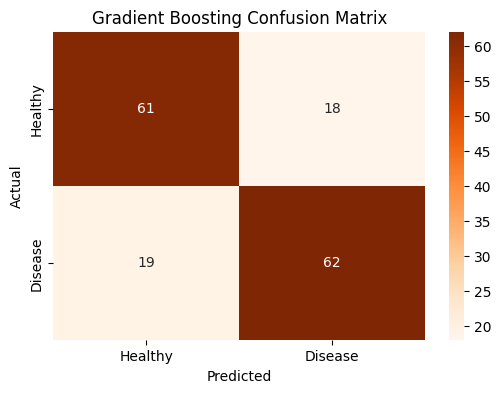

In [9]:
# Gradient Boosting Classifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)
gb_pred = gb.predict(X_test_scaled)

print("Gradient Boosting Accuracy = ", accuracy_score(y_test, gb_pred))
print("Gradient Boosting Precision = ", precision_score(y_test, gb_pred))
print("Gradient Boosting Recall = ", recall_score(y_test, gb_pred))
print("Gradient Boosting F1 Score = ", f1_score(y_test, gb_pred))

cm_gb = confusion_matrix(y_test, gb_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

Random Forest Classifier performs the best out of the three. Random Forest Classifier shows a recall of 81.481%. In medical context, recall is the most important metric. It shows that it can correctly identify patients with a heart disease. Missing a heart disease patient (False Negative) is more dangerous than incorrectly identifying a healthy patient (False Positive). The Random Forest Classifier also shows the highest F1 score of 0.8. This shows that it can handle False Positives and False Negatives better tha Decision Tree and Gradient Boosting models.

In [11]:
# 6. Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_tuned_pred = best_model.predict(X_test_scaled)
print("\nTuned Model Report:\n", classification_report(y_test, y_tuned_pred))

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Tuned Model Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



Metric      Baseline RF     Tuned RF

Accuracy        0.79            0.77

Recall          0.81            0.81

F1-Score        0.80            0.78

After Hyper Parameter Tuning, the accuracy decreases from 79% to 77%. But the Recall stayed the same at 81%. By increasing the min_samples_split, the risk of overfitting the patterns, is reduced.